<a href="https://colab.research.google.com/github/osvaldomaguey/Ecommerce-analysis/blob/main/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind
from scipy.stats import levene
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:
El dataset no tiene valores ausentes ni errores el tipo de datos en ninguna de sus columnas

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
print(df['gasto'].describe())

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
cols_categoricas = ['landing', 'region', 'dispositivo','traffic_source', 'user_type']
print("\nConteo de categorías:")
print(df[cols_categoricas].describe())
for col in cols_categoricas:
    print(f"\n--- Conteos para {col} ---")
    print(df[col].value_counts())


Conteo de categorías:
       landing region dispositivo traffic_source user_type
count    40000  40000       40000          40000     40000
unique       2      5           2              4         2
top          B  Norte      Mobile        Organic     Nuevo
freq     20018  11166       24829          17987     26033

--- Conteos para landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- Conteos para region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- Conteos para dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- Conteos para traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- Conteos para user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ **Comentario**:
Todas las columnas tienen valores esperados y no presentan sentinels

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['landing']=='A') & (df['converted'])==1]['gasto'] #completa el código
gasto_B = df[(df['landing']=='B') & (df['converted'])==1]['gasto'] #completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba T student

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay diferencia en la conversión entre los clientes de la página A y la página B
- **Hipótesis alternativa (H₁):** Si existe una diferencia en la conversión entre los clientes de la página A y la página B

In [ ]:
# Aplicar prueba
t_stat, p_value=ttest_ind(gasto_A, gasto_B)


# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


In [ ]:
l_stat, p_value_var=levene(gasto_A, gasto_B)
print(f"Estadístico : {l_stat}")
print(f"Valor p: {p_value_var}")
if p_value < 0.05:
    print(f"p-value = {p_value_var:.4f}")
    print("❌ Las varianzas NO son iguales")
else:
    print(f"p-value = {p_value_var:.4f}")
    print("✅ Las varianzas son iguales")

Estadístico : 29.17646453202917
Valor p: 6.875301988016449e-08
p-value = 0.0000
❌ Las varianzas NO son iguales


In [ ]:
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")
if p_value < 0.05:
    print(f"p-value = {p_value:.4f}")
    print("Hay diferencia significativa entre los grupos")
else:
    print(f"p-value = {p_valuer:.4f}")
    print("No hay diferencia significativa entre los grupos")
print('gasto_A - gasto_B')

Estadístico : -12.843805911325239
Valor p: 1.1149523921280718e-37
p-value = 0.0000
Hay diferencia significativa entre los grupos
gasto_A - gasto_B


In [ ]:
media_gasto_A=gasto_A.mean()
media_gasto_B=gasto_B.mean()
print('La media para gasto A es:', media_gasto_A)
print('La media para gasto B es:', media_gasto_B)
print('La diferencia es de:', media_gasto_B-media_gasto_A)

La media para gasto A es: 7.6793849464518065
La media para gasto B es: 10.968762114097313
La diferencia es de: 3.2893771676455064


### 📝 Conclusión e interpretación


**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Con base en la prueba t, encontramos evidencia estadística de que el gasto promedio difiere entre las dos páginas.

En promedio, los usuarios que gastaron en la página B gastaron 3.2893 más que en la página A.

La prueba no implica causalidad ni evalua si la diferencia justifica un cambio desde una perspectiva de negocio.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀): No existe diferencia en la tasa de conversión entre la página A y B**
- **Hipótesis alternativa (H₁): Sí, existe diferencia en la tasa de conversión entre la página A y B?**

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
exitos = [conversiones['A'],conversiones['B']]
observaciones = [totales['A'], totales['B']]

In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos,observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")
if p_value<0.05:
    print('Hay diferencia en la conversión de los grupos')
else:
    print('No existe diferencia en la conversión de los grupos')

tasa_A = exitos[0]/observaciones[0]
tasa_B = exitos[1]/observaciones[1]
print()
print(f"Tasa de éxito página A: {tasa_A:.4f}%")
print(f"Tasa de éxito página B: {tasa_B:.4f}%")
print(f'Diferencia tasa de éxito: {tasa_B - tasa_A:.4f}%')

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Hay diferencia en la conversión de los grupos

Tasa de éxito página A: 0.1257%
Tasa de éxito página B: 0.1596%
Diferencia tasa de éxito: 0.0338%


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
En base a la prueba Z para proporciones se observa que hay evidencia estadística de que la conversión en la papa página B es mayor a la página A (en 0.033%).

La prueba no implica causalidad ni evalua si la diferencia justifica un cambio desde la perspectiva del negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** Qué un cliente convierta o no, no depende del canal por el que llegó el usuario.
- **Hipótesis alternativa (H₁):** el canal por el que llega al cliente sí influye en que convierta o no.

In [ ]:
tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico: {chi2_stat: .4f}")
print(f"Valor p: {p_value:.4f}")
if p_value < 0.05:
    print('Hay evidencia de que el canal influye en la conversión')
else:
    print('No hay evidencia de que el canal influya en la conversión')

Estadístico:  8.6621
Valor p: 0.0341
Hay evidencia de que el canal influye en la conversión


In [ ]:
tablapct = pd.crosstab(df['traffic_source'], df['converted'], normalize = "index")*100
print(tablapct)

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza hipótesis nula

**Interpretación de negocio:**  
En base a la prueba chi-cuadrada se observa que hay evidencia estadística de que el canal por el que llego el cliente si tiene influencia en la conversión. No obstante, dicha influencia esta entre 0.1% - 1.2%. Aunque es estadísticamente significativo, no necesariamente quiere decir que sea práctico. La prueba no implica causalidad ni evalua si la diferencia justifica un cambio desde la perspectiva del negocio.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario influye en la conversión
- **Hipótesis alternativa (H₁):** El tipo de usuario no tiene influencia alguna en la conversión

In [ ]:
tabla = pd.crosstab(df['user_type'], df['converted'])
print(tabla)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [ ]:
tablapct = pd.crosstab(df['user_type'], df['converted'], normalize ='index')*100
print(tablapct)

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico: {chi2_stat: .4f}")
print(f"Valor p: {p_value:.4f}")
if p_value < 0.05:
    print('Hay evidencia de que el tipo de usuario influye en la conversión')
else:
    print('No hay evidencia de que el tipo de unsiario influya en la conversión')

Estadístico:  0.5135
Valor p: 0.4736
No hay evidencia de que el tipo de unsiario influya en la conversión


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula

**Interpretación de negocio:**  
En base a la prueba chi-cuadrada se observa que NO hay evidencia estadística de que el el tipo de usuario influya en la conversión.

- No se necesitan estrategias diferenciadas por tipo de usuario
- Se puede usar la misma página para clientes nuevos o recurrentes
  
La prueba no implica causalidad ni evalua si la diferencia justifica un cambio desde la perspectiva del negocio.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

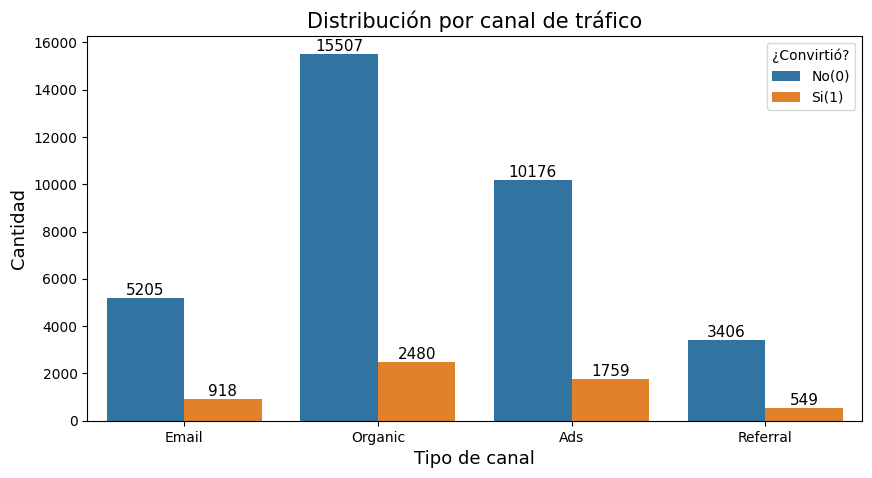

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='traffic_source',hue='converted')
for bar in ax.patches:
    height=bar.get_height()
    ax.text(x=bar.get_x()
            +bar.get_width()/2,
            y=height, s=height,
            ha='center', va='bottom',
            fontsize=11)
plt.title('Distribución por canal de tráfico', fontsize=15)
plt.xlabel('Tipo de canal',fontsize=13)
plt.ylabel('Cantidad', fontsize=13)
plt.legend(title='¿Convirtió?', labels=['No(0)','Si(1)'])
plt.show()

✍️ **Comentario**:

Grafico: Distribución por canal de tráfico:

Se puede observar por cada canal el total de usuarios que convirtieron y los que no. No se confunda con el canal con mejor desempeño ya que la tasa de conversión se muestra en el siguiente gráfico.
El análisis no mide por canal el costo de adquisición por cliente (CAC), ni el valor de vida del clientes (LTV)

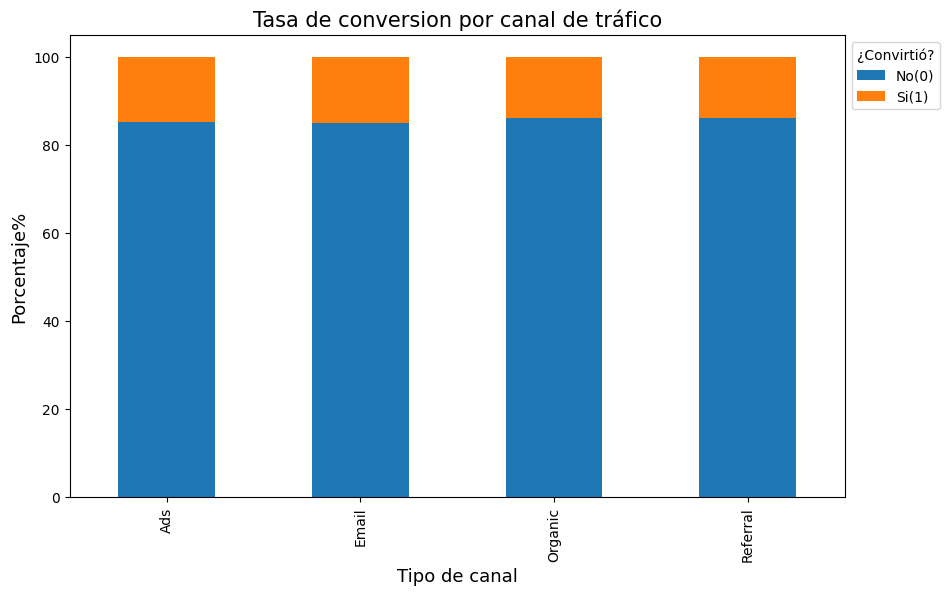

In [ ]:
tabla = pd.crosstab(df['traffic_source'],df['converted'], normalize='index')*100
tabla.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Tasa de conversion por canal de tráfico',fontsize=15)
plt.xlabel('Tipo de canal',fontsize=13)
plt.ylabel('Porcentaje%', fontsize=13)
plt.legend(title='¿Convirtió?', labels=['No(0)','Si(1)'], bbox_to_anchor=(1,1))
plt.show()

✍️ **Comentario**:

Gráfico Tasa de conversión por canal de tráfico:

Se observa una tasa de conversión muy similar en todos los canales, y la diferencia va desde 0.1% - 1.2%. Esto quiere decir, que independientemente de la versión de la página las conversiones son muy similares por cualquier medio que el cliente llego a la empresa.

### Relación entre el tipo de usuario y la conversión

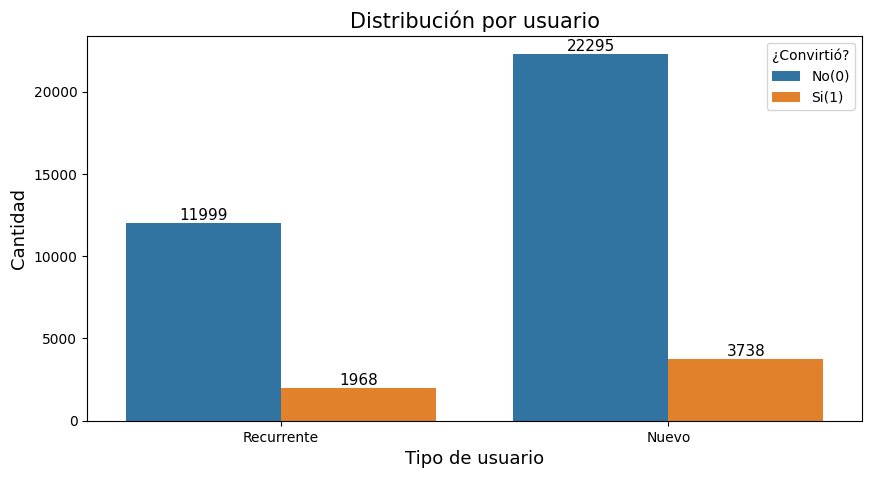

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='user_type',hue='converted')
for bar in ax.patches:
    height=bar.get_height()
    ax.text(x=bar.get_x()
            +bar.get_width()/2,
            y=height, s=height,
            ha='center', va='bottom',
            fontsize=11)
plt.title('Distribución por usuario', fontsize=15)
plt.xlabel('Tipo de usuario',fontsize=13)
plt.ylabel('Cantidad', fontsize=13)
plt.legend(title='¿Convirtió?', labels=['No(0)','Si(1)'])
plt.show()

✍️ **Comentario**:

Gráfico de distribución por usuario:

Muestra la cantidad de conversiones que se obtuvieron por el tipo de usuario (nuevo o recurrente). No se interprete como el tipo de cliente que más le conviene a la empresa, ya que la tasa de conversión se muestra en el siguiente gráfico.

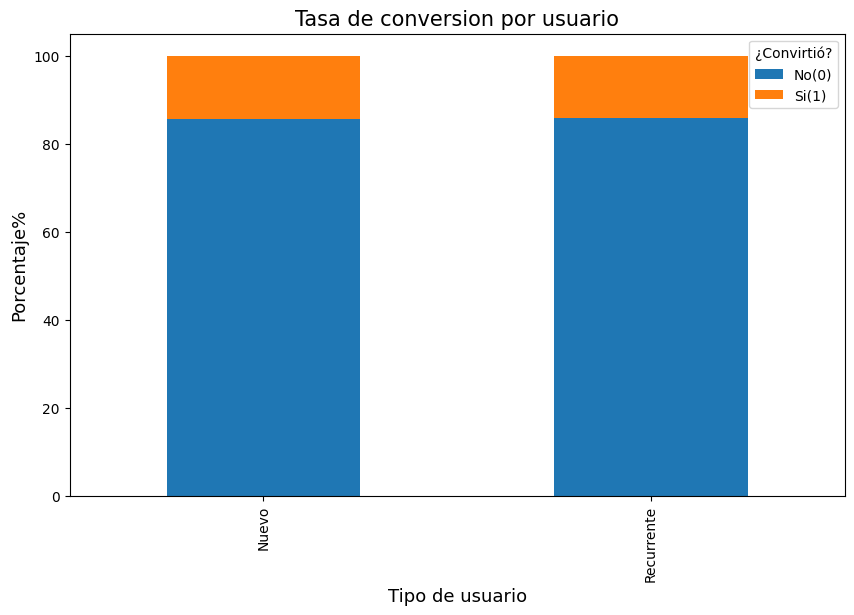

In [ ]:
tabla = pd.crosstab(df['user_type'],df['converted'], normalize='index')*100
tabla.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Tasa de conversion por usuario',fontsize=15)
plt.xlabel('Tipo de usuario',fontsize=13)
plt.ylabel('Porcentaje%', fontsize=13)
plt.legend(title='¿Convirtió?', labels=['No(0)','Si(1)'], bbox_to_anchor=(1,1))
plt.show()

✍️ **Comentario**:

Gráfico Tasa de conversión por tipo de usuario:

Se observa una tasa de conversión muy similar en ambos tipos de usario, la cual es 14.00% - 14.35% para usuario recurrente y usuario nuevo respectivamente. Esto quiere decir, que independientemente de la versión de la página las conversiones son muy similares entre los usuarios.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- El gasto promedio en la página B es mayor al de la A en $3.28
- La diferencia es estadisticamente significativa (p value = 0.0000), por lo que es poco probable que se deba al azar o coincidencia
- **Interpretación:**
Aunque la pagina B tenga un mejor desempeño en comparación con la página A, la prueba no implica causalidad y la diferencia en el ingreso para la empresa es mínima, por lo que puede no ser una diferencia relevante en terminos de negocio.

<br>

**Tasa de conversión:**
- La tasa de conversión es mayor en la página B en comparación con la página A en un 0.0338%
- La diferencia es estadísticamente significativa. (p value = 0.0000)
- **Interpretación:**
Esta prueba no implica causalidad, aunque la página B tiene una mayor tasa de conversión que la página A, la diferencia en el ingreso es muy pequeña. por lo que no necesariamente justifica un cambio en la estrategia del negocio.

---

#### 📊 **Segmentación por fuente de tráfico**
- Hay evidencias estadística significativa (p value = 0.0341) que indica que el canal de tráfico por el que llega al cliente influye en la conversión de la página
- La tasa de conversión por canal de tráfico es muy similar en cualquiera de los 4 canales, la variación va desde 0.1% a 1.2%
- **Interpretación:**
Pese a qué hay ciertos canales que tienen mayor porcentaje de conversión (Ads = 14.73% y Email = 14.99%) y la diferencia sea estadísticamente significativa. No justifica necesariamente un cambio en la estrategia del negocio. Ya que la variación de dicha diferencia es muy baja (Organico = 13.78% y Refreido = 13.88%)
 ---

#### 📊 **Segmentación por tipo de usuario**
- No hay evidencia estadística de que el tipo de usuario influya en la conversión (p value = 0.47)
- La conversion por tipo de usuario es muy similar, para nuevos es 14.35% y para recurrentes es de 14.09%
- **Interpretación:**
El tipo de usuario no influye en la conversión de cualquiera de las 2 páginas. Por lo que no es necesario hacer ajustes en la estrategia de la empresa por tipo de usuario
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
**Desempeño de la Página A vs Página B**

**Recomendación:**

● No realizar un cambio inmediato de la página A por la B únicamente con base en este resultado.

● Antes de escalar la versión B, proyectar el impacto financiero anual para determinar si la mejora justifica el cambio.

● Diseñar una nueva iteración del experimento con modificaciones más diferenciadas que puedan generar un incremento más relevante en ingresos.

● En este momento, la diferencia detectada no representa una ventaja competitiva clara en términos de negocio.

**Influencia del Canal de Tráfico**

**Recomendación**

● Mantener la estrategia actual de inversión por canal.

● Priorizar el análisis de rentabilidad por canal (costo vs ingreso generado) antes de considerar redistribuciones presupuestales.

● Explorar optimizaciones dentro de cada canal en lugar de modificar la estrategia global de adquisición.

● Calcular CAC y LTV a 30 dias que permita vislumbrar el costo beneficio de cualquier cambio.

**Influencia del Tipo de Usuario**

**Recomendación**

● Experimentar segmentar por otras variables del cliente

● Mantener una experiencia homogénea en la página.

● Enfocar futuras pruebas en variables con mayor potencial de impacto, como mensajes clave, propuesta de valor o incentivos.

#### **Limitaciones del Estudio**

Para una correcta interpretación de los resultados, es importante considerar las siguientes limitaciones:
1. Las pruebas identifican diferencias, pero no explican causas:
Las pruebas estadísticas utilizadas (prueba T, Z y Chi-cuadrada) permiten detectar si existen diferencias entre grupos, pero no determinan qué elemento específico generó el cambio en comportamiento.
Esto implica que, aunque una versión tenga mejor desempeño, no podemos atribuir la mejora a un componente particular de la página.
2. Significancia estadística no implica relevancia económica:
Con tamaños de muestra amplios, es posible detectar diferencias reales pero pequeñas desde el punto de vista financiero.
En este caso, aunque las diferencias son estadísticamente significativas, su impacto en ingresos es limitado, lo que reduce su relevancia estratégica.
3. No se evaluó impacto a mediano o largo plazo:
El análisis se enfocó en conversión inmediata y gasto promedio. No se incluyeron métricas como:
Retención, recompra, valor de vida del cliente (LTV), y percepción de marca.
Es posible que el impacto real difiera en horizontes temporales más amplios.
4. Variables externas no controladas:
Aunque el experimento controla la versión de página, factores como estacionalidad, calidad del tráfico, tipo de productos, barreras de conversión o cambios en el mercado podrían influir en el comportamiento del usuario.
5. Segmentación limitada
El análisis por canal y tipo de usuario fue general. No se exploraron segmentaciones más específicas como:
Dispositivo, Ubicación geográfica, Edad, Género, y Fuente específica dentro de cada canal. Es posible que existan subsegmentos donde el impacto sea mayor.